In [2]:
## load the 3 swap seqs with their selected SEAM configs
#   peak26256 : 100_k200   |   peak84030 : 300_k300   |   peak27535 : 100_k300
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
import numpy as np, pandas as pd, h5py, torch
from pathlib import Path
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle

SIT = Path("/grid/koo/home/pmantill/projects/situate/data")
LIB = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib")
ADAPTER = 15      # annotation coords are insert[15:215]; offset into the 230bp insert

peaks = {0: "peak26256", 1: "peak84030", 2: "peak27535_Reversed"}   # situate row -> peak (config already baked into the foreground artifact)
wt_seqs, labels = {}, {}
for i, peak in peaks.items():
    with h5py.File(LIB / f"{peak}.h5") as f:
        wt_seqs[i] = f.attrs["wt_seq_str"]        # 230bp WT insert string
        labels[i] = float(f.attrs["mean_value"])  # measured K562 log2FC

with h5py.File(SIT / "mcs_k562/attr.h5") as f:
    fg = f["attr"][:3]            # (3,4,200) projected foreground (what was annotated)
    preds = f["predictions"][:3]  # WT model pred
names = (SIT / "mcs_k562/names.txt").read_text().splitlines()[:3]


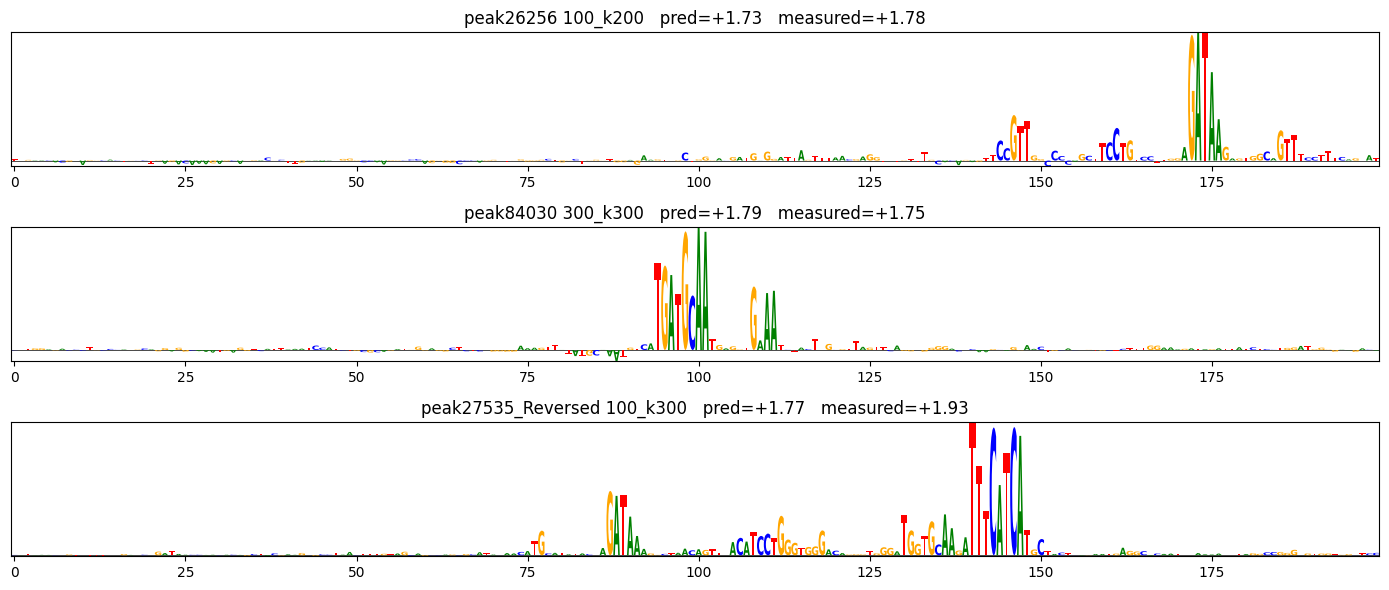

In [3]:
# show the three foreground logos with pred + measured label in the title
import logomaker, matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(14, 6))
for ax, i in zip(axes, range(3)):
    logomaker.Logo(pd.DataFrame(fg[i].T, columns=list("ACGT")), ax=ax)
    ax.set_title(f"{names[i]}   pred={preds[i]:+.2f}   measured={labels[i]:+.2f}")
    ax.set_yticks([])
plt.tight_layout()


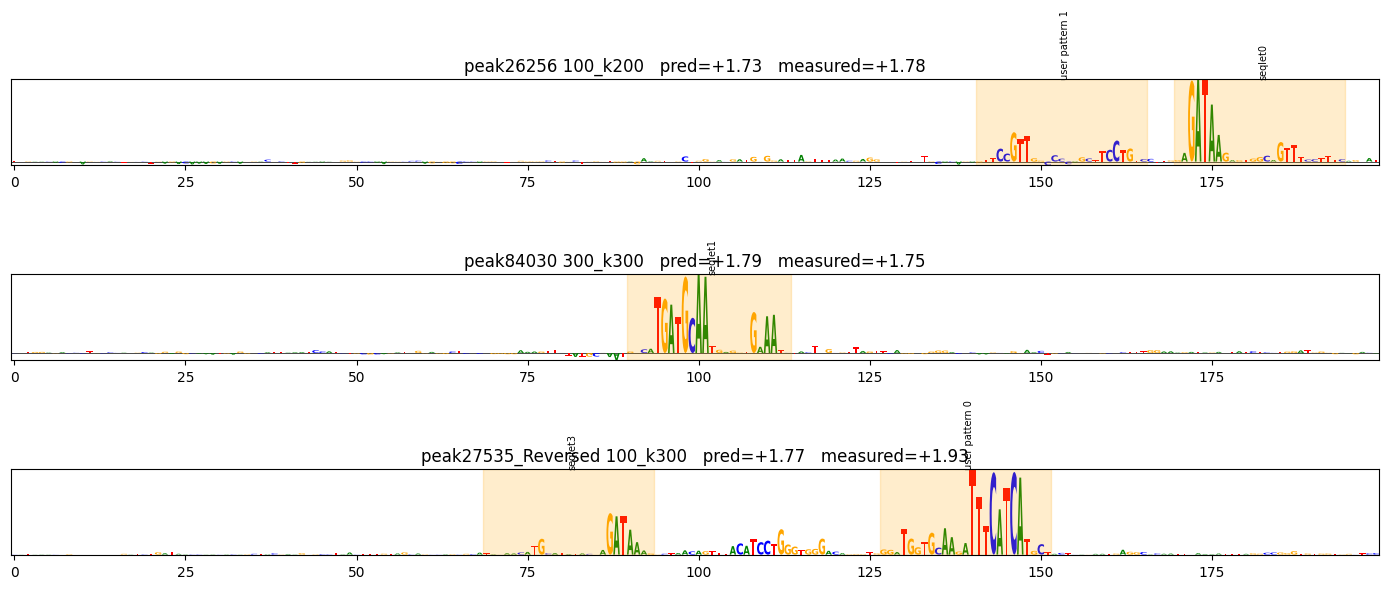

In [4]:
# load manual annotations from situate and show logo annotations
ann = pd.read_csv(SIT / "annotations/mcs_k562/edits.csv")
motifs = {i: list(zip(g.start, g.end, g.motif_name))             # annotated motifs, var-region coords [0,200)
          for i, g in ann[ann.sequence_name < 3].groupby("sequence_name")}

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
for ax, i in zip(axes, range(3)):
    logomaker.Logo(pd.DataFrame(fg[i].T, columns=list("ACGT")), ax=ax)
    for s, e, m in motifs[i]:
        ax.axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
        ax.text((s + e) / 2, ax.get_ylim()[1], m, ha="center", va="bottom", fontsize=7, rotation=90)
    ax.set_title(f"{names[i]}   pred={preds[i]:+.2f}   measured={labels[i]:+.2f}")
    ax.set_yticks([])
plt.tight_layout()


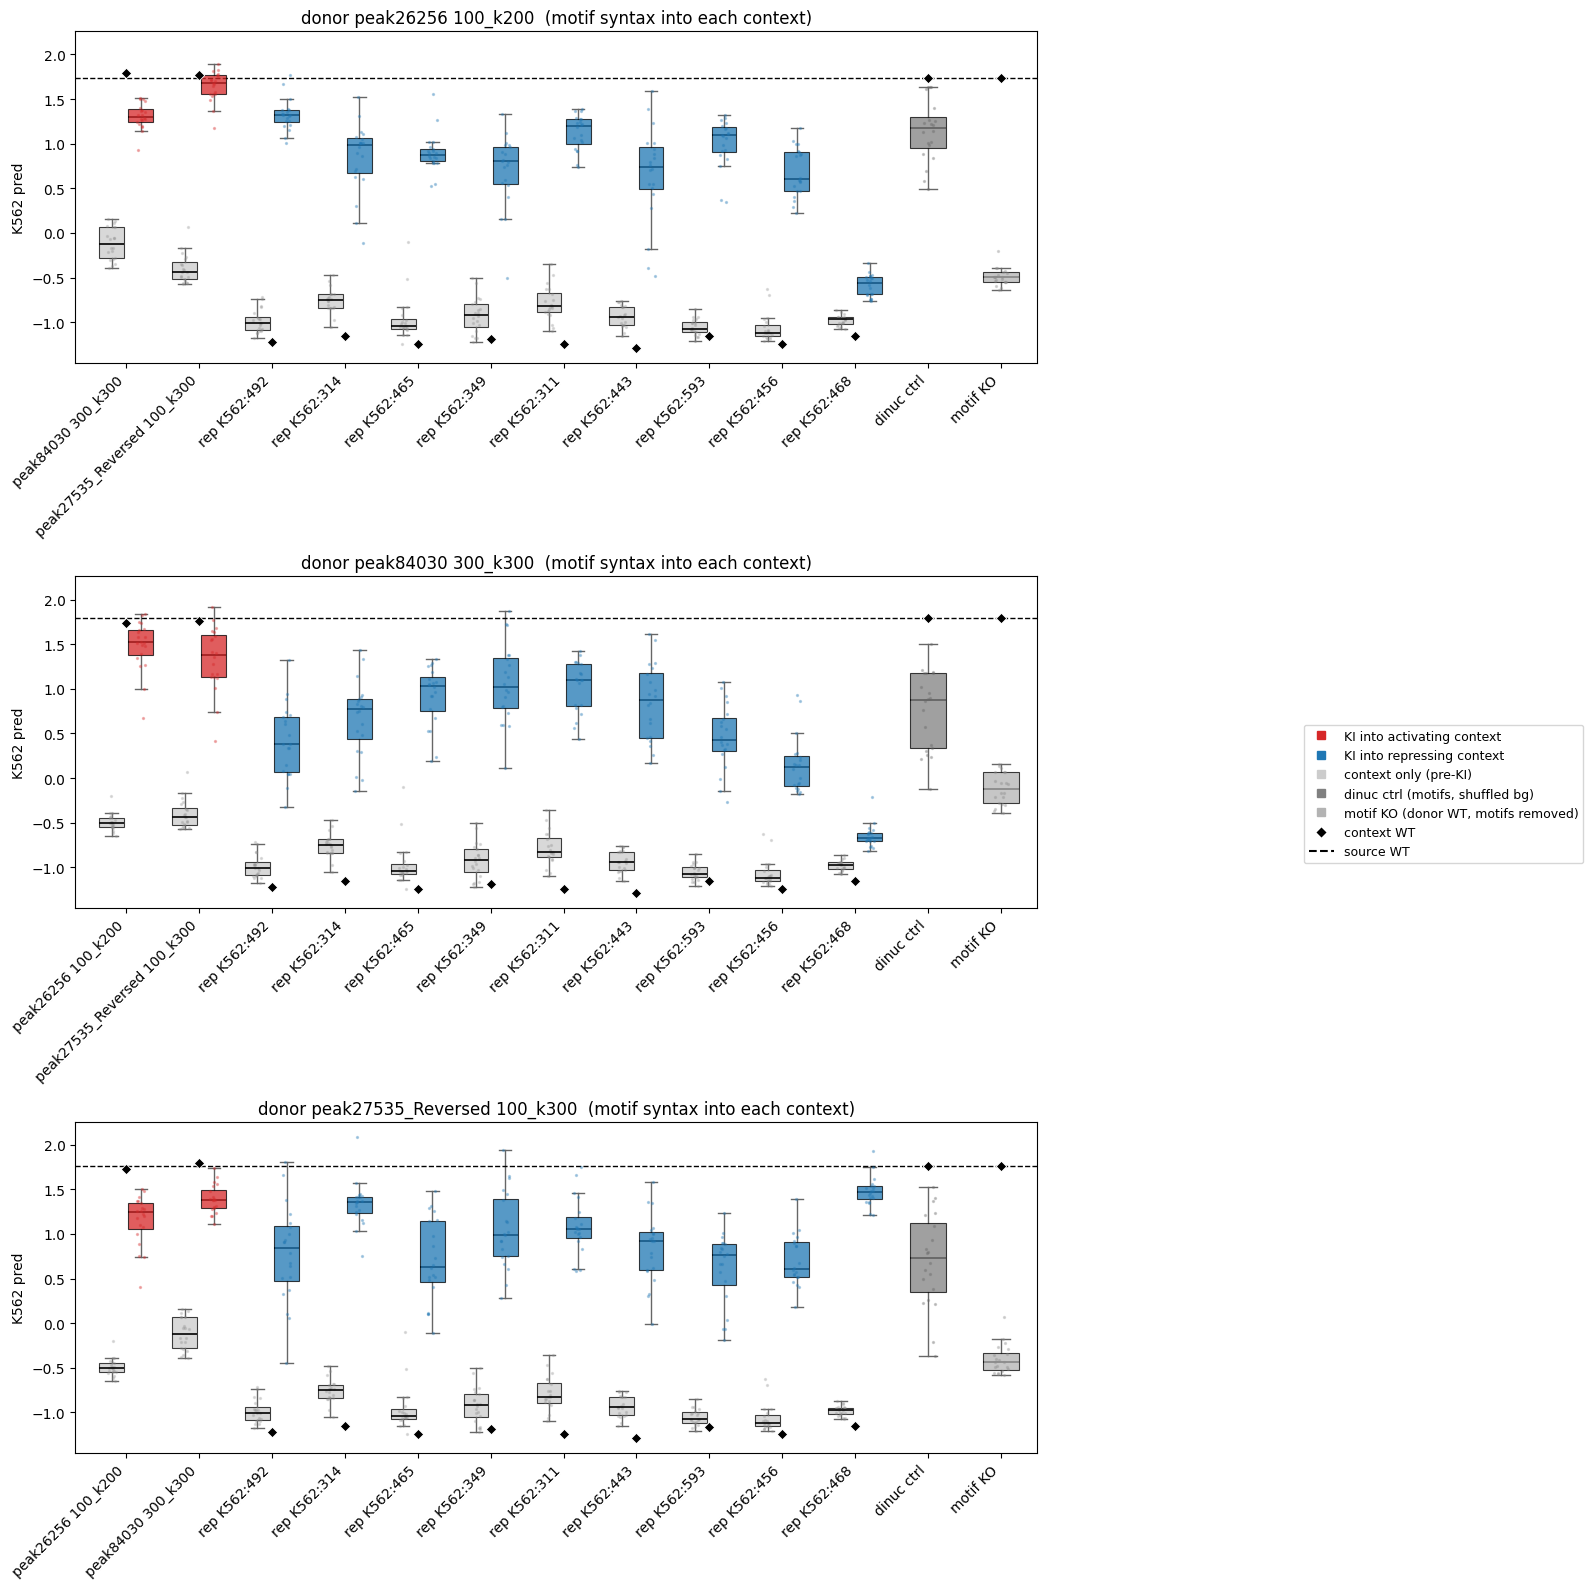

In [12]:
# create swap library: donor motif-syntax (WT motif segments) -> acceptor neutralized context, score, plot
N = 20
CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
from alphagenome_encoder_ft import EncoderMPRAModel
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()  # (4,51) promoter+barcode

@torch.no_grad()
def score(ohe):                                       # (B,4,230) -> (B,) K562 pred
    out = []
    for k in range(0, len(ohe), 512):
        b = ohe[k:k + 512]
        x = torch.cat([b, suffix.expand(len(b), -1, -1)], 2)
        out.append(model(x.transpose(1, 2).cuda()).cpu().numpy())
    return np.concatenate(out)

# WT strings + annotated motifs for all 13 seqs. high = the 3 swap seqs (rows 0-2); low = repressing K562 (rows 3+)
libj = pd.read_pickle("/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/"
                      "SEAM_jointlib900/libraries/jointlib900_library.pkl")["df"]
libj = libj[libj.cell_type == "K562"].set_index("seq_idx")
all_names = (SIT / "mcs_k562/names.txt").read_text().splitlines()
seq_str = dict(wt_seqs)
for i, nm in enumerate(all_names):
    if nm.startswith("rep "):
        seq_str[i] = libj.loc[int(nm.split(":")[1]), "sequence"]
mot = {i: [(s + ADAPTER, e + ADAPTER) for s, e in zip(g.start, g.end)]   # motif regions in 230bp insert coords
       for i, g in ann.groupby("sequence_name")}
high = [0, 1, 2]
low = [i for i, nm in enumerate(all_names) if nm.startswith("rep ") and i in mot]   # only annotated reps (e.g. row 12 has no annotations)

def carrier(i):   # n donor backgrounds for the dinuc ctrl: dinuc-shuffled, donor motifs restored (motifs intact, rest neutralized)
    wt = one_hot_encode(seq_str[i]).float()
    blk = dinucleotide_shuffle(wt.unsqueeze(0), n=N, random_state=0)[0]
    for s, e in mot[i]:
        blk[:, :, s:e] = wt[:, s:e]
    return blk

def context(i):   # n acceptor contexts: WT flanks kept, own motifs neutralized (dinuc-shuffled at motif positions)
    wt = one_hot_encode(seq_str[i]).float()
    shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N, random_state=1)[0]
    ctx = wt.unsqueeze(0).repeat(N, 1, 1).clone()
    for s, e in mot[i]:
        ctx[:, :, s:e] = shuf[:, :, s:e]
    return ctx

def inject(d, ctx):   # overwrite donor d's motif segments (single fixed WT syntax) into each of the N target contexts
    wt = one_hot_encode(seq_str[d]).float()
    out = ctx.clone()
    for s, e in mot[d]:
        out[:, :, s:e] = wt[:, s:e]
    return out

# one fixed donor motif syntax injected into each target's N neutralized contexts -> N seqs per (d, target);
# two opposite controls (rightmost): dinuc ctrl = donor motifs intact on N shuffled backgrounds (syntax, no context);
#                                    motif KO = donor WT seq with its own motifs neutralized (context, no motifs) = pre[d]
swap = {d: {} for d in high}
ctrl = {}
for d in high:
    ctrl[d] = score(carrier(d))                                  # (N,) motifs intact, donor background dinuc-shuffled
    for t in [x for x in high if x != d] + low:
        swap[d][t] = score(inject(d, context(t)))                # (N,) donor syntax in N neutralized target contexts

pre = {i: score(context(i)) for i in high + low}                 # (N,) target context pre-injection (own motifs neutralized, no donor); pre[d] = donor motif-KO ctrl
wt_all = {i: float(p) for i, p in enumerate(score(torch.stack(   # original WT K562 pred per seq
    [one_hot_encode(seq_str[i]).float() for i in range(len(all_names))])))}

# one row per donor; per target a dodged pair: gray context-only box (pre-KI) + KI box colored by target class
# (activating context = red, repressing context = blue). two rightmost controls in gray: dinuc ctrl + motif KO.
# black diamond = context seq's own WT (donor WT at both controls); dashed line = donor (source) WT.
RED, BLUE = "#d62728", "#1f77b4"   # activating (high) vs repressing (low) target context

def draw_boxes(ax, data, positions, width, facecolors, zorder):
    bp = ax.boxplot(data, positions=positions, widths=width, patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", lw=1.2), whiskerprops=dict(color="0.4"),
                    capprops=dict(color="0.4"), boxprops=dict(lw=0.8))
    for patch, fc in zip(bp["boxes"], facecolors):
        patch.set_facecolor(fc); patch.set_alpha(0.75); patch.set_zorder(zorder)
    return bp

rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(high), 1, figsize=(13, 16), sharey=True)
for ax, d in zip(axes, high):
    targets = [x for x in high if x != d] + low
    pos = np.arange(len(targets) + 2)
    tpos, cpos = pos[:-2], pos[-2:]                              # target positions | dinuc ctrl, motif-KO ctrl
    ki_fc = [RED if t in high else BLUE for t in targets]       # color KI box by target context class
    draw_boxes(ax, [pre[t] for t in targets], tpos - 0.2, 0.34, ["0.8"] * len(targets), 1)   # context only (pre-KI)
    draw_boxes(ax, [swap[d][t] for t in targets], tpos + 0.2, 0.34, ki_fc, 3)                # donor motifs injected (KI)
    draw_boxes(ax, [ctrl[d], pre[d]], cpos, 0.5, ["0.5", "0.7"], 3)                          # dinuc ctrl | motif KO
    for xi, t in zip(tpos, targets):
        ax.scatter(xi - 0.2 + rng.uniform(-0.06, 0.06, len(pre[t])), pre[t], s=2, color="0.55", alpha=0.25, zorder=2)
        ax.scatter(xi + 0.2 + rng.uniform(-0.06, 0.06, len(swap[d][t])), swap[d][t], s=2,
                   color=RED if t in high else BLUE, alpha=0.3, zorder=4)
    ax.scatter(cpos[0] + rng.uniform(-0.1, 0.1, len(ctrl[d])), ctrl[d], s=2, color="0.4", alpha=0.3, zorder=4)
    ax.scatter(cpos[1] + rng.uniform(-0.1, 0.1, len(pre[d])), pre[d], s=2, color="0.55", alpha=0.3, zorder=4)
    ax.scatter(pos, [wt_all[t] for t in targets] + [wt_all[d], wt_all[d]], marker="D", s=28, color="black",
               edgecolor="white", lw=0.6, zorder=5)
    ax.axhline(wt_all[d], color="black", ls="--", lw=1)
    ax.set_xticks(pos)
    ax.set_xticklabels([all_names[t] for t in targets] + ["dinuc ctrl", "motif KO"], rotation=45, ha="right")
    ax.set_title(f"donor {names[d]}  (motif syntax into each context)")
    ax.set_ylabel("K562 pred")

fig.legend(handles=[plt.Line2D([], [], marker="s", color=RED, ls=""),
                    plt.Line2D([], [], marker="s", color=BLUE, ls=""),
                    plt.Line2D([], [], marker="s", color="0.8", ls=""),
                    plt.Line2D([], [], marker="s", color="0.5", ls=""),
                    plt.Line2D([], [], marker="s", color="0.7", ls=""),
                    plt.Line2D([], [], marker="D", color="black", mec="white", ls=""),
                    plt.Line2D([], [], color="black", ls="--")],
           labels=["KI into activating context", "KI into repressing context", "context only (pre-KI)",
                   "dinuc ctrl (motifs, shuffled bg)", "motif KO (donor WT, motifs removed)", "context WT", "source WT"],
           loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
fig.subplots_adjust(right=0.80)


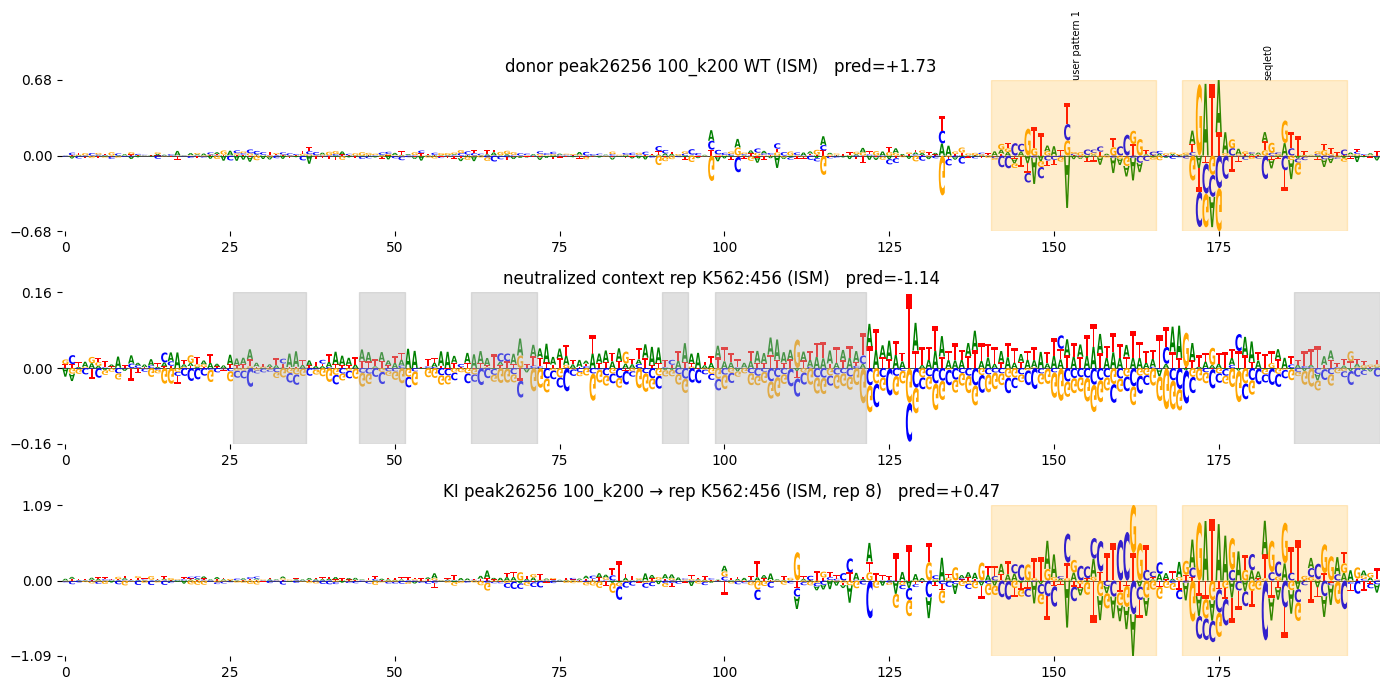

In [24]:
# inspect one knock-in: donor WT (top), neutralized context (mid), KI (bottom).
# all three are saturation-ISM logos (mean-centered across channels = hypothetical), so all obey PROJECT.
# set `sel` 0/1/2 to step donors; target context + which of the N reps random each run.
sel = 0
PROJECT = False   # False: full 4-channel saturation ISM (hypothetical). True: project onto the actual base.

d = high[sel]
rng = np.random.default_rng()
t = int(rng.choice([i for i in high + low if i != d]))   # random target context
r = int(rng.integers(N))                                 # which of the N reps

@torch.no_grad()
def ism(seq):                                            # (4,230) one-hot -> (200,4) ISM over var region
    block = seq.unsqueeze(0).repeat(800, 1, 1).clone()
    for j, p in enumerate(range(ADAPTER, ADAPTER + 200)):
        block[j * 4:j * 4 + 4, :, p] = torch.eye(4)      # rows j*4..+3 = the 4 single-base mutants at p
    m = score(block).reshape(200, 4)
    m -= m.mean(1, keepdims=True)                        # hypothetical: center across channels
    return m * seq[:, ADAPTER:ADAPTER + 200].numpy().T if PROJECT else m

don_seq = one_hot_encode(seq_str[d]).float()             # (4,230) donor WT
ctx_seq = context(t)[r]                                  # (4,230) neutralized acceptor
ki_seq  = inject(d, context(t))[r]                       # (4,230) donor syntax knocked into that context
p_ctx, p_ki = float(score(ctx_seq.unsqueeze(0))[0]), float(score(ki_seq.unsqueeze(0))[0])
panels = [(ism(don_seq), f"donor {names[d]} WT (ISM)   pred={wt_all[d]:+.2f}"),
          (ism(ctx_seq), f"neutralized context {all_names[t]} (ISM)   pred={p_ctx:+.2f}"),
          (ism(ki_seq),  f"KI {names[d]} → {all_names[t]} (ISM, rep {r})   pred={p_ki:+.2f}")]

fig, axes = plt.subplots(3, 1, figsize=(14, 7))
for ax, (mat, ttl) in zip(axes, panels):                # each panel autoscaled on its own y-range
    logomaker.Logo(pd.DataFrame(mat.T if mat.shape[0] == 4 else mat, columns=list("ACGT")), ax=ax)
    ax.set_title(ttl)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_yticks(np.round(np.linspace(*ax.get_ylim(), 3), 2))   # 3 ticks to denote scale
for s, e, m in motifs[d]:                                # donor motifs: annotate WT + mark on KI panel
    axes[0].axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
    axes[0].text((s + e) / 2, axes[0].get_ylim()[1], m, ha="center", va="bottom", fontsize=7, rotation=90)
    axes[2].axvspan(s - 0.5, e - 0.5, color="orange", alpha=0.2)
for s, e in mot[t]:                                      # target's own (neutralized) motif positions
    axes[1].axvspan(s - ADAPTER - 0.5, e - ADAPTER - 0.5, color="0.7", alpha=0.4)
plt.tight_layout()


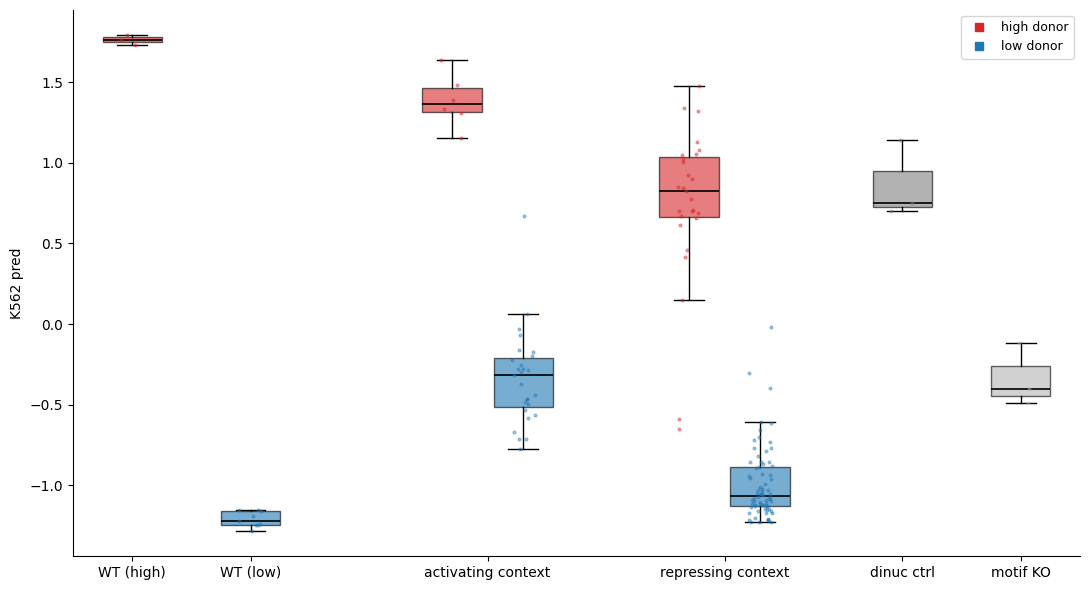

In [11]:
# classic pooled view. color = DONOR class (high=red, low=blue). each context holds two boxes:
# high-donor knock-in vs low-donor knock-in. each point = mean over the 20 reps for one (donor,target) pair.
act_hd = np.array([swap[d][t].mean() for d in high for t in high if t != d])                  # high donor -> activating ctx
rep_hd = np.array([swap[d][t].mean() for d in high for t in low])                             # high donor -> repressing ctx
act_ld = np.array([score(inject(d, context(t))).mean() for d in low for t in high])           # low donor  -> activating ctx
rep_ld = np.array([score(inject(d, context(t))).mean() for d in low for t in low if t != d])  # low donor  -> repressing ctx
wt_high = np.array([wt_all[i] for i in high])
wt_low  = np.array([wt_all[i] for i in low])
dinuc   = np.array([ctrl[d].mean() for d in high])
motifko = np.array([pre[d].mean()  for d in high])

boxes = [(wt_high, 0, RED), (wt_low, 1, BLUE),       # endogenous WT
         (act_hd, 2.7, RED), (act_ld, 3.3, BLUE),    # activating context: high vs low donor
         (rep_hd, 4.7, RED), (rep_ld, 5.3, BLUE),    # repressing context: high vs low donor
         (dinuc, 6.5, "0.5"), (motifko, 7.5, "0.7")] # controls
ticks  = [0, 1, 3, 5, 6.5, 7.5]
labels = ["WT (high)", "WT (low)", "activating context", "repressing context", "dinuc ctrl", "motif KO"]

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot([b[0] for b in boxes], positions=[b[1] for b in boxes], widths=0.5,
                patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.2))
for patch, b in zip(bp["boxes"], boxes):
    patch.set_facecolor(b[2]); patch.set_alpha(0.6)
for data, x, c in boxes:
    ax.scatter(x + rng.uniform(-0.1, 0.1, len(data)), data, s=4, color=c, alpha=0.4, zorder=3)
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=0, ha="center")
ax.legend(handles=[plt.Line2D([], [], marker="s", color=RED, ls=""), plt.Line2D([], [], marker="s", color=BLUE, ls="")],
          labels=["high donor", "low donor"], loc="best", fontsize=9)
ax.set_ylabel("K562 pred")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

out = Path("/grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/results")
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "swap_experiment.png", dpi=200, bbox_inches="tight")
